In [1]:
import pandas as pd

# 1. Load the training data
try:
    df_train = pd.read_csv('twitter_training.csv', encoding='utf-8')
    print("--- Training Data Loaded Successfully ---")
    print("\nTraining Data Head:")
    print(df_train.head())
    print("\nTraining Data Info:")
    df_train.info()
except FileNotFoundError:
    print("Error: 'twitter_training.csv' not found. Please check the file name and path.")
except Exception as e:
    print(f"An error occurred while loading training data: {e}")


# 2. Load the validation data
try:
    df_val = pd.read_csv('twitter_validation.csv', encoding='utf-8')
    print("\n\n--- Validation Data Loaded Successfully ---")
    print("\nValidation Data Head:")
    print(df_val.head())
    print("\nValidation Data Info:")
    df_val.info()
except FileNotFoundError:
    print("Error: 'twitter_validation.csv' not found. Please check the file name and path.")
except Exception as e:
    print(f"An error occurred while loading validation data: {e}")

--- Training Data Loaded Successfully ---

Training Data Head:
   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   B

In [2]:
df_train = pd.read_csv("./twitter_training.csv")
df_val = pd.read_csv("./twitter_validation.csv")

In [3]:
df_train

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [4]:
df_val

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...,...,...
994,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
995,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
996,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
997,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [5]:
df_train = df_train.rename(columns={'2401': 'ID', 'Borderlands': 'platform', 'Positive': 'sentimen', 'im getting on borderlands and i will murder you all ,': 'text'})
df_val = df_val.rename(columns={'3364': 'ID', 'Facebook': 'platform', 'Irrelevant': 'sentimen', 'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣': 'text'})

In [6]:
print(df_train["sentimen"].value_counts())
print(df_val["sentimen"].value_counts())

sentimen
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
sentimen
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64


In [7]:
print("Platform Counts - Training")
print(df_train["platform"].value_counts())
print(20*"==")
print("Platform Counts - Validation")
print(df_val["platform"].value_counts())

Platform Counts - Training
platform
Microsoft                            2400
MaddenNFL                            2400
TomClancysRainbowSix                 2400
LeagueOfLegends                      2394
CallOfDuty                           2394
Verizon                              2382
CallOfDutyBlackopsColdWar            2376
ApexLegends                          2376
Facebook                             2370
WorldOfCraft                         2364
Dota2                                2364
NBA2K                                2352
TomClancysGhostRecon                 2346
Battlefield                          2346
FIFA                                 2340
Overwatch                            2334
Xbox(Xseries)                        2334
johnson&johnson                      2328
Amazon                               2316
HomeDepot                            2310
PlayStation5(PS5)                    2310
CS-GO                                2304
Cyberpunk2077                        230

In [8]:
# We're dropping unneeded columns

df_train = df_train.drop(["ID","platform"], axis=1)
df_val = df_val.drop(["ID","platform"], axis=1)

In [9]:
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")
print(f"Duplicates: {df_train.duplicated().sum()}")
print(f"missing data: {sum(df_train.isna().sum())}")

print(20*"==")

print(f"Rows: {df_val.shape[0]}, Columns: {df_val.shape[1]}")
print(f"Duplicates: {df_val.duplicated().sum()}")
print(f"missing data: {sum(df_val.isna().sum())}")

Rows: 74681, Columns: 2
Duplicates: 4909
missing data: 686
Rows: 999, Columns: 2
Duplicates: 1
missing data: 0


In [10]:
kolom1=len(df_train.columns)
for i in range (0, kolom1):
  df_train=df_train[df_train.iloc[:,i]!='?']
  df_train=df_train[df_train.iloc[:,i]!='']
  df_train=df_train[~df_train.iloc[:,i].isna()]
df_train.info()
df_train.drop_duplicates(keep= 'first',inplace = True)

kolom=len(df_val.columns)
for i in range (0, kolom):
  df_val=df_val[df_val.iloc[:,i]!='?']
  df_val=df_val[df_val.iloc[:,i]!='']
  df_val=df_val[~df_val.iloc[:,i].isna()]
df_val.info()
df_val.drop_duplicates(keep= 'first',inplace = True)

print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")
print(f"Duplicates: {df_train.duplicated().sum()}")
print(f"missing data: {sum(df_train.isna().sum())}")

print(20*"==")

print(f"Rows: {df_val.shape[0]}, Columns: {df_val.shape[1]}")
print(f"Duplicates: {df_val.duplicated().sum()}")
print(f"missing data: {sum(df_val.isna().sum())}")

<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  73995 non-null  object
 1   text      73995 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  999 non-null    object
 1   text      999 non-null    object
dtypes: object(2)
memory usage: 15.7+ KB
Rows: 69768, Columns: 2
Duplicates: 0
missing data: 0
Rows: 998, Columns: 2
Duplicates: 0
missing data: 0


In [11]:
!pip install emoji nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.7 MB/s eta 0:00:00


In [12]:
import re
import string
import emoji
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Pastikan resource NLTK terunduh
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')           # kalau belum pernah diunduh
nltk.download('omw-1.4')           # opsional tapi sering diperlukan
nltk.download('punkt')             # untuk tokenisasi, jika kamu pakai word_tokenize()

# Inisialisasi
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Kamus singkatan umum (bisa diperluas)
abbreviation_map = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lol": "laughing out loud",
    "omg": "oh my god",
    "thx": "thanks",
    "pls": "please",
    "plz": "please",
    "dont": "do not",
    "cant": "cannot",
    "wont": "will not",
    "ive": "i have",
    "ill": "i will",
    "didnt": "did not",
    "doesnt": "does not",
    "isnt": "is not",
    "wasnt": "was not",
    "havent": "have not",
    "shouldnt": "should not",
    "couldnt": "could not",
    "wouldnt": "would not",
}

def get_wordnet_pos(word):
    """
    Helper function:
    Mengubah POS tag (part-of-speech) menjadi format yang bisa dipakai lemmatizer.
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)


def preprocess_text(text):
    """
    Function for text preprocessing for English sentiment analysis.
    Includes:
      - lowercase
      - emoji handling
      - URL and number removal
      - punctuation removal
      - short form expansion
      - stopword removal
      - lemmatization
    """

    # Ensure input is string
    if not isinstance(text, str):
        text = str(text)

    # Lowercase
    text = text.lower()

    # Replace emojis with text description
    text = emoji.demojize(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Expand common short forms
    words = text.split()
    expanded_words = [abbreviation_map.get(w, w) for w in words]
    text = ' '.join(expanded_words)

    # Tokenize and remove stopwords + lemmatize
    filtered_words = []
    for word in text.split():
        if word not in stop_words:
            pos = get_wordnet_pos(word)
            lemma = lemmatizer.lemmatize(word, pos)
            filtered_words.append(lemma)

    # Join cleaned text
    processed_text = ' '.join(filtered_words)

    # Clean extra whitespace
    processed_text = re.sub(r'\s+', ' ', processed_text).strip()

    return processed_text


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Data Reloaded and Renamed. 'TweetText' column is ready.

Starting text cleaning for training data...
Text cleaning complete. 'clean_text' column created.


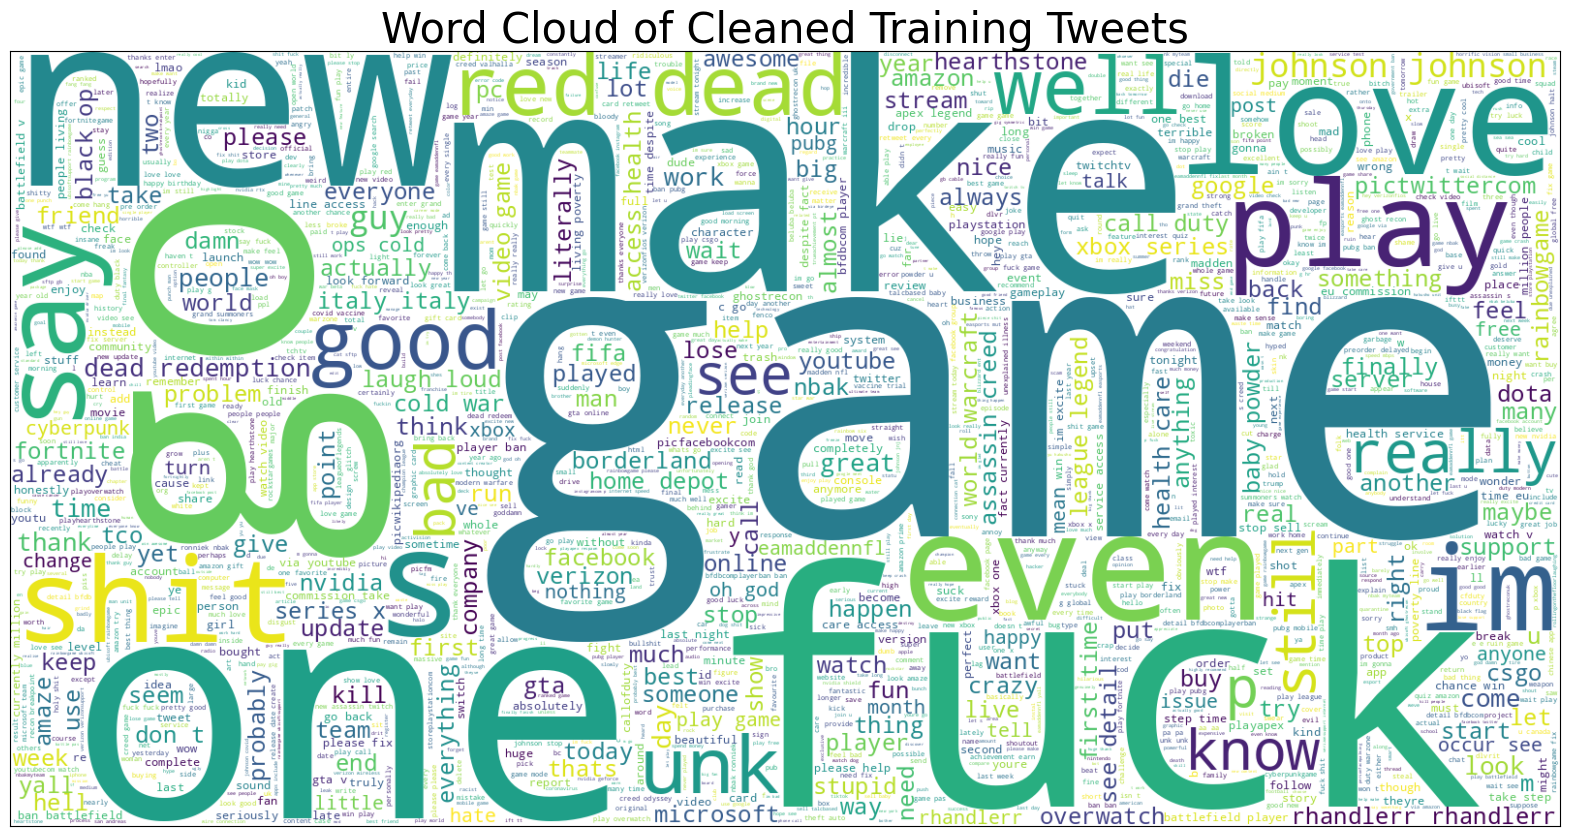

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# -------------------------------------------------------------------
# 1. FIX DATA LOADING AND RENAME COLUMNS
# -------------------------------------------------------------------
try:
    # Reload with header=None to treat the first row as data
    df_train = pd.read_csv("./twitter_training.csv", encoding='utf-8', header=None)

    # Assign the correct column names (raw text is in the 4th column)
    df_train.columns = ['ID', 'Entity', 'Sentiment', 'TweetText']

    # Remove rows where the TweetText is missing, just in case
    df_train.dropna(subset=['TweetText'], inplace=True)

    print("Data Reloaded and Renamed. 'TweetText' column is ready.")
except FileNotFoundError:
    print("Error: 'twitter_training.csv' not found. Please ensure the file is uploaded.")

# -------------------------------------------------------------------
# 2. APPLY THE FUNCTION TO CREATE 'clean_text'
# -------------------------------------------------------------------
print("\nStarting text cleaning for training data...")

# CRITICAL: This line calls your defined function and CREATES the 'clean_text' column
df_train['clean_text'] = df_train['TweetText'].apply(preprocess_text)
print("Text cleaning complete. 'clean_text' column created.")


# -------------------------------------------------------------------
# 3. RUN THE PLOT CODE
# -------------------------------------------------------------------
plt.figure(figsize=(20, 20))
wc = WordCloud(
    max_words=2000,
    width=1600,
    height=800,
    stopwords=STOPWORDS,
    background_color='white'
).generate(' '.join(df_train['clean_text']))

plt.imshow(wc, interpolation='bilinear')
plt.xticks([])
plt.yticks([])
plt.title('Word Cloud of Cleaned Training Tweets', fontsize=30)
plt.show()

In [14]:
df_val['clean_text'] = df_val['text'].apply(preprocess_text)
print(df_val[['text', 'clean_text']])

                                                  text  \
0    BBC News - Amazon boss Jeff Bezos rejects clai...   
1    @Microsoft Why do I pay for WORD when it funct...   
2    CSGO matchmaking is so full of closet hacking,...   
3    Now the President is slapping Americans in the...   
4    Hi @EAHelp I’ve had Madeleine McCann in my cel...   
..                                                 ...   
994  ⭐️ Toronto is the arts and culture capital of ...   
995  tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...   
996  Today sucked so it’s time to drink wine n play...   
997  Bought a fraction of Microsoft today. Small wins.   
998  Johnson & Johnson to stop selling talc baby po...   

                                            clean_text  
0    bbc news amazon bos jeff bezos reject claim co...  
1    microsoft pay word function poorly samsungus c...  
2    csgo matchmaking full closet hack truly awful ...  
3    president slap american face really commit unl...  
4    hi eahelp i’v

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define TF-IDF vectorizer (you can tune max_features, ngram_range etc. as needed)
tfidf = TfidfVectorizer(max_features=17000, ngram_range=(1,2))



In [16]:
# Fit TF-IDF on training text and transform train and test text
X_train = tfidf.fit_transform(df_train['clean_text'])
X_test = tfidf.transform(df_val['clean_text'])

# Assuming your sentiment labels are in 'label' column in both dfs
y_train = df_train['Sentiment']
y_test = df_val['sentimen']


In [17]:
print(df_train.columns.tolist())
print(df_val.columns.tolist())

['ID', 'Entity', 'Sentiment', 'TweetText', 'clean_text']
['sentimen', 'text', 'clean_text']


In [18]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import inspect

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluasi model klasifikasi multi-class:
      - ROC & AUC (macro)
      - Akurasi
      - F1-score (macro)
      - ROC Curve Plot
    Dapat digunakan untuk SVM, Random Forest, Logistic Regression, dll.
    """

    # Prediksi label
    y_pred = model.predict(X_test)

    # Coba ambil skor probabilitas atau decision function
    if hasattr(model, "decision_function"):
        decision_scores = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        decision_scores = model.predict_proba(X_test)
    else:
        raise ValueError(f"Model {model_name} tidak mendukung ROC (butuh decision_function atau predict_proba)")

    # Binarisasi label untuk ROC multi-class
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    # Hitung ROC curve dan AUC untuk tiap kelas
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], decision_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # AUC rata-rata (macro)
    roc_auc["macro"] = roc_auc_score(y_test_bin, decision_scores, average="macro", multi_class="ovr")

    # Akurasi dan F1-score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"======= Evaluasi Klasifikasi {model_name} =======")
    print(f"Akurasi Klasifikasi     : {accuracy * 100:.2f}%")
    print(f"F-measure (macro avg)   : {f1:.3f}")
    print(f"AUC rata-rata (macro)   : {roc_auc['macro']:.3f}")
    print("=" * 45)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    # Garis diagonal (baseline)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Multi-Class {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "f1_macro": f1,
        "auc_macro": roc_auc["macro"]
    }


Logistic Regression

In [19]:
# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Accuracy: 0.9048096192384769
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.91      0.87      0.89       171
    Negative       0.88      0.94      0.91       266
     Neutral       0.94      0.88      0.91       285
    Positive       0.89      0.92      0.90       276

    accuracy                           0.90       998
   macro avg       0.91      0.90      0.90       998
weighted avg       0.91      0.90      0.90       998



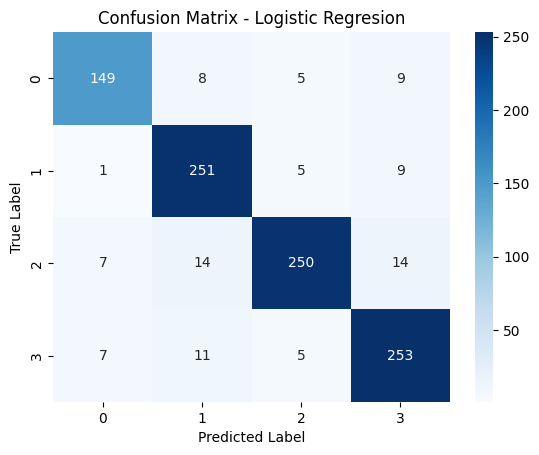

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_predlr = model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_predlr))
print("Classification Report:\n", classification_report(y_test, y_predlr))

cm = confusion_matrix(y_test, y_predlr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regresion')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


======= Evaluasi Klasifikasi Logistic Regresion =======
Akurasi Klasifikasi     : 90.48%
F-measure (macro avg)   : 0.903
AUC rata-rata (macro)   : 0.973


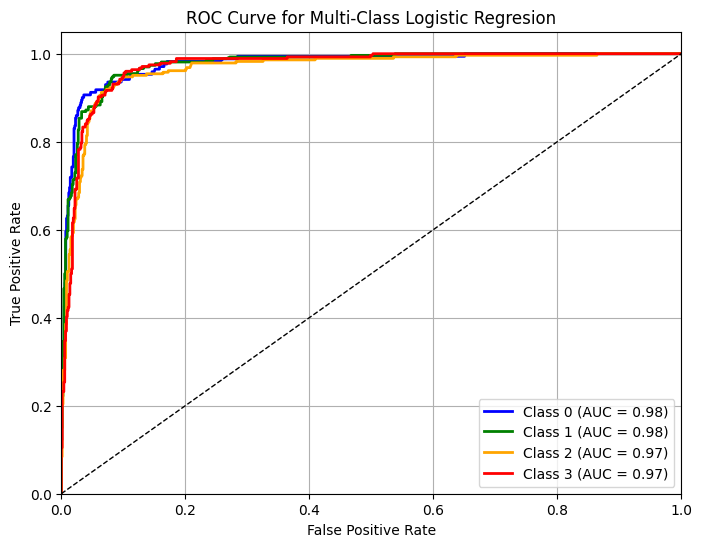

In [21]:
lr_results = evaluate_model(model, X_test, y_test, model_name="Logistic Regresion")



Tugas pakai RandomForest dan Xgboost
coba make model lain juga.

Random Forest

--- Training Random Forest Model ---
Original labels found: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
Encoded labels will be: [0 1 2 3]
Fitting model...
Model fitting complete.

--- Random Forest Evaluation ---
Accuracy: 0.9629

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.98      0.96      0.97       171
    Negative       0.95      0.97      0.96       266
     Neutral       0.97      0.95      0.96       285
    Positive       0.96      0.97      0.97       276

    accuracy                           0.96       998
   macro avg       0.96      0.96      0.96       998
weighted avg       0.96      0.96      0.96       998

Plotting Confusion Matrix...


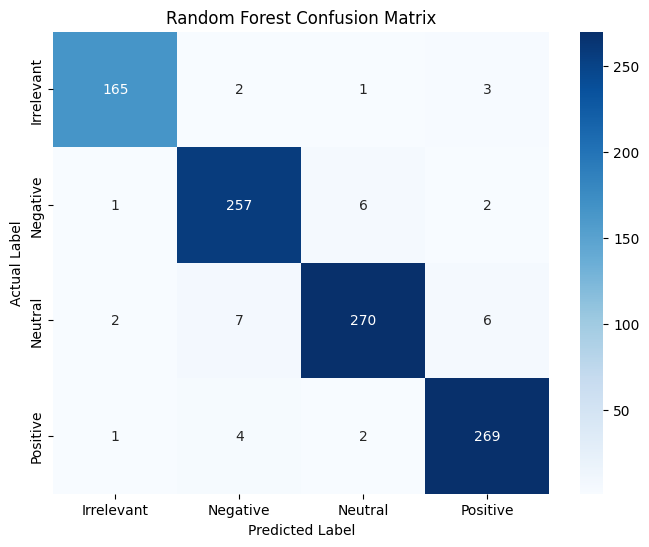

In [22]:
# Title: Random Forest Model
# Description: Trains and evaluates a Random Forest classifier.
# You can copy this code into a new cell in your notebook.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np # Will need this for label mapping

print("--- Training Random Forest Model ---")

# 1. Encode Labels
# We fit the encoder ONLY on the training data to learn the classes
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
# We transform the test data using the *same* fitted encoder
y_test_encoded = le.transform(y_test)

# Get the class names in the correct order for reports
class_names = le.classes_
print(f"Original labels found: {class_names}")
print(f"Encoded labels will be: {np.unique(y_train_encoded)}")

# 2. Initialize and Train the Model
# n_jobs=-1 uses all available CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Fitting model...")
# Use X_train as per your variable name
rf_model.fit(X_train, y_train_encoded)
print("Model fitting complete.")

# 3. Make Predictions
# Use X_test as per your variable name
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate the Model
print("\n--- Random Forest Evaluation ---")
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

print("\nClassification Report:")
# Use target_names to show original string labels
print(classification_report(y_test_encoded, y_pred_rf, target_names=class_names))

# 5. Plot Confusion Matrix
print("Plotting Confusion Matrix...")
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



XGBoost Model

In [ ]:
# 1. Install XGBoost
!pip install xgboost

--- Training XGBoost Model ---
Original labels found: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
Encoded labels will be: [0 1 2 3]
Fitting model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:16:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model fitting complete.

--- XGBoost Evaluation ---
Accuracy: 0.7395

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.88      0.60      0.72       171
    Negative       0.65      0.87      0.74       266
     Neutral       0.81      0.63      0.71       285
    Positive       0.74      0.81      0.78       276

    accuracy                           0.74       998
   macro avg       0.77      0.73      0.74       998
weighted avg       0.76      0.74      0.74       998

Plotting Confusion Matrix...


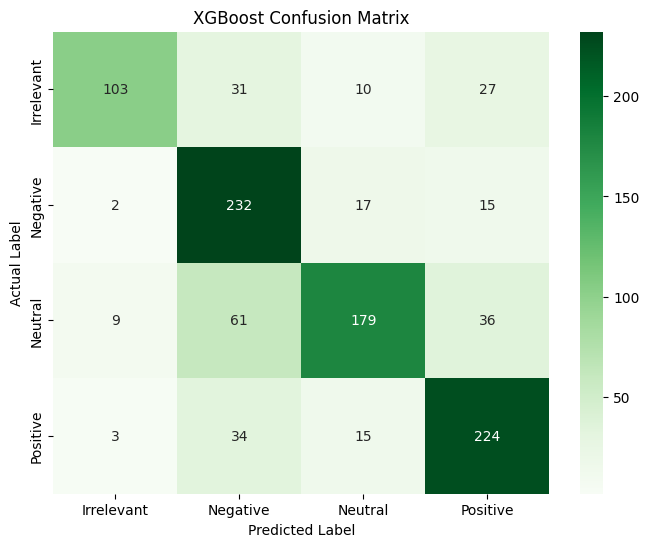

In [ ]:
# Title: XGBoost Model
# Description: Trains and evaluates an XGBoost classifier.

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- PRE-REQUISITE ---
# This code assumes you have in memory:
# X_train: Your TF-IDF features for the training set (from tfidf.fit_transform)
# X_test: Your TF-IDF features for the test set (from tfidf.transform)
# y_train: Your original training labels (e.g., 'Positive', 'Negative')
# y_test: Your original test labels

# If you already ran the LabelEncoder in the Random Forest cell,
# you can reuse the y_train_encoded, y_test_encoded, and class_names variables.
# If running this cell standalone, we re-encode:

print("--- Training XGBoost Model ---")

# 1. Encode Labels (XGBoost *requires* integer labels)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Get the class names in the correct order
class_names = le.classes_
print(f"Original labels found: {class_names}")
print(f"Encoded labels will be: {np.unique(y_train_encoded)}")


# 2. Initialize and Train the Model
# use_label_encoder=False is recommended in modern XGBoost versions
# eval_metric='mlogloss' is common for multi-class classification (or 'logloss' for binary)
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False,
                              eval_metric='mlogloss', n_jobs=-1)

print("Fitting model...")
# Use X_train as per your variable name
xgb_model.fit(X_train, y_train_encoded)
print("Model fitting complete.")

# 3. Make Predictions
# Use X_test as per your variable name
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate the Model
print("\n--- XGBoost Evaluation ---")
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}")

print("\nClassification Report:")
# Use target_names to show original string labels
print(classification_report(y_test_encoded, y_pred_xgb, target_names=class_names))

# 5. Plot Confusion Matrix
print("Plotting Confusion Matrix...")
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



SVM ( Support Vector Model )

--- Training Support Vector Machine (SVM) Model ---
Labels encoded. Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
Fitting model...
Model fitting complete.

--- SVM Evaluation ---
Accuracy: 0.9359

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.94      0.93      0.93       171
    Negative       0.95      0.95      0.95       266
     Neutral       0.96      0.92      0.94       285
    Positive       0.90      0.95      0.92       276

    accuracy                           0.94       998
   macro avg       0.94      0.94      0.94       998
weighted avg       0.94      0.94      0.94       998

Plotting Confusion Matrix...


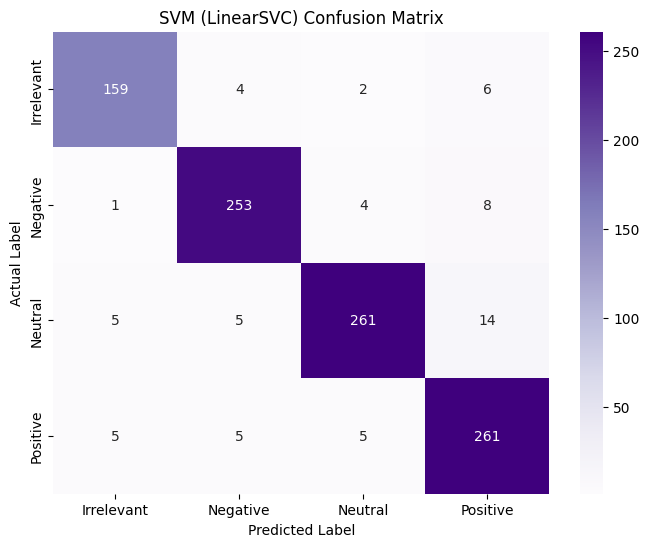

In [23]:
# Title: Support Vector Machine (SVM) Model
# Description: Trains and evaluates a LinearSVC (SVM) classifier.
# You can copy this code into a new cell in your notebook.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- PRE-REQUISITE ---
# This code assumes you have in memory:
# X_train: Your TF-IDF features for the training set
# X_test: Your TF-IDF features for the test set
# y_train: Your original training labels
# y_test: Your original test labels

print("--- Training Support Vector Machine (SVM) Model ---")

# 1. Encode Labels
# If you already ran the LabelEncoder in another cell,
# you can reuse y_train_encoded, y_test_encoded, and class_names.
# We include it here to be safe and standalone.
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_names = le.classes_
print(f"Labels encoded. Classes: {class_names}")

# 2. Initialize and Train the Model
# LinearSVC is a strong baseline for text classification.
# We increase 'max_iter' just in case it doesn't converge on complex data.
svm_model = LinearSVC(random_state=42, max_iter=2000, C=1.0)
print("Fitting model...")
svm_model.fit(X_train, y_train_encoded)
print("Model fitting complete.")

# 3. Make Predictions
y_pred_svm = svm_model.predict(X_test)

# 4. Evaluate the Model
print("\n--- SVM Evaluation ---")
accuracy_svm = accuracy_score(y_test_encoded, y_pred_svm)
print(f"Accuracy: {accuracy_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_svm, target_names=class_names))

# 5. Plot Confusion Matrix
print("Plotting Confusion Matrix...")
cm_svm = confusion_matrix(y_test_encoded, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('SVM (LinearSVC) Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()